<a href="https://colab.research.google.com/github/sonjoy1s/CNN_Pipeline/blob/main/CNNPipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import kagglehub
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader,Dataset,Subset
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split

# Dataset DownLoad from Kaggle

In [2]:
# Download latest version
path = kagglehub.dataset_download("pritpal2873/multiple-skin-disease-detection-and-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'multiple-skin-disease-detection-and-classification' dataset.
Path to dataset files: /kaggle/input/multiple-skin-disease-detection-and-classification


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [4]:
categories = os.listdir(path)
print(categories)
for root, categories, files in os.walk(path):
  if len(categories) > 1 :
    data_dir = root
    break
Class_found = os.listdir(data_dir)
print("Class Found :",Class_found)

['Skin Cancer Dataset']
Class Found : ['Acitinic Keratosis', 'Pigmented Benign Keratosis', 'Melanoma', 'Vascular Lesion', 'Squamous Cell Carcinoma', 'Basal Cell Carcinoma', 'Seborrheic Keratosis', 'Dermatofibroma', 'Nevus']


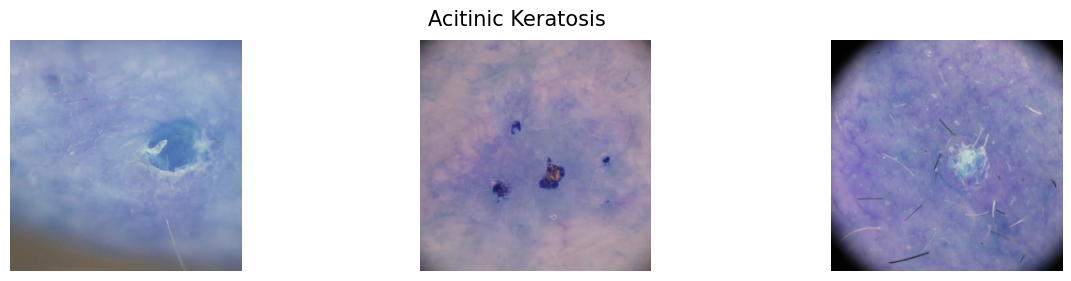

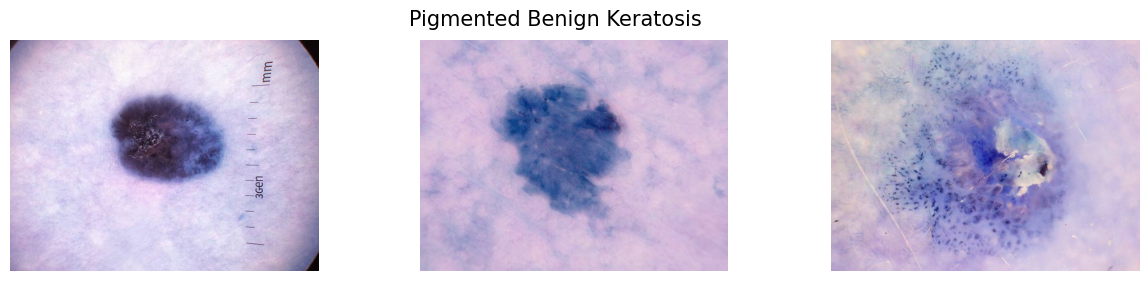

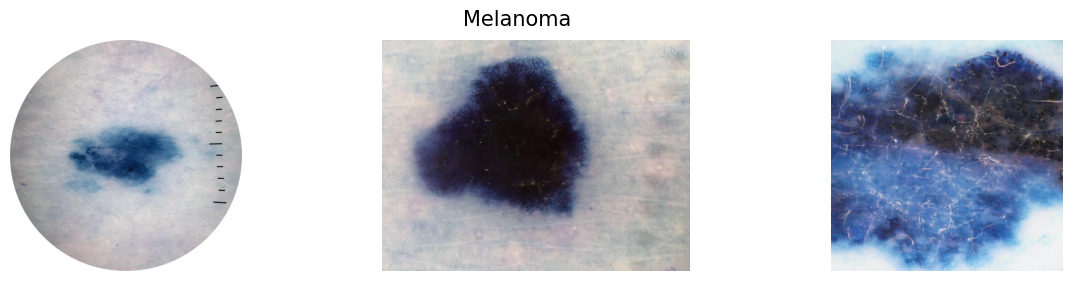

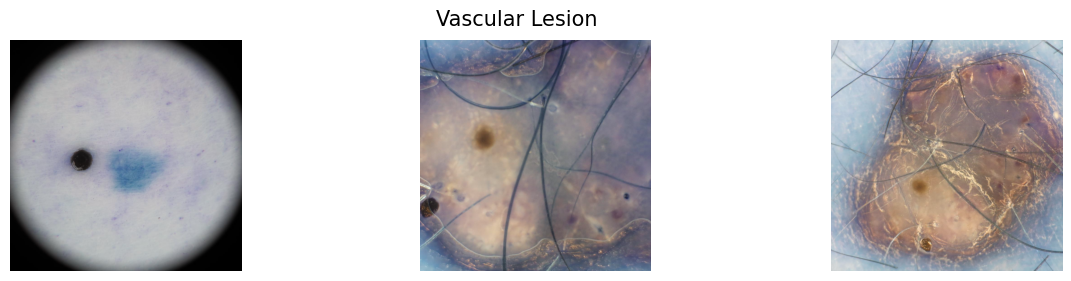

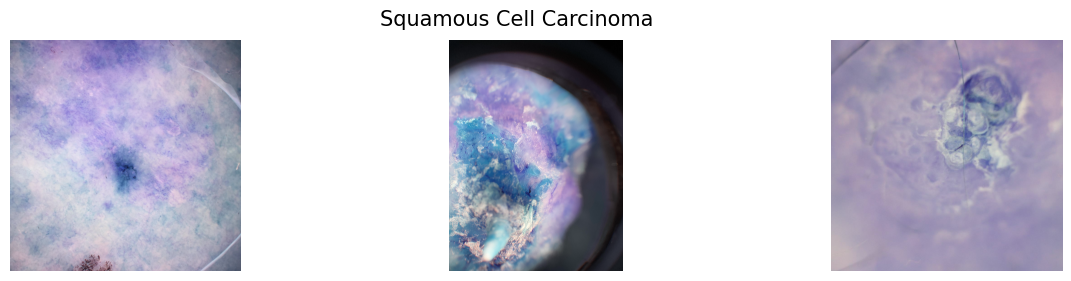

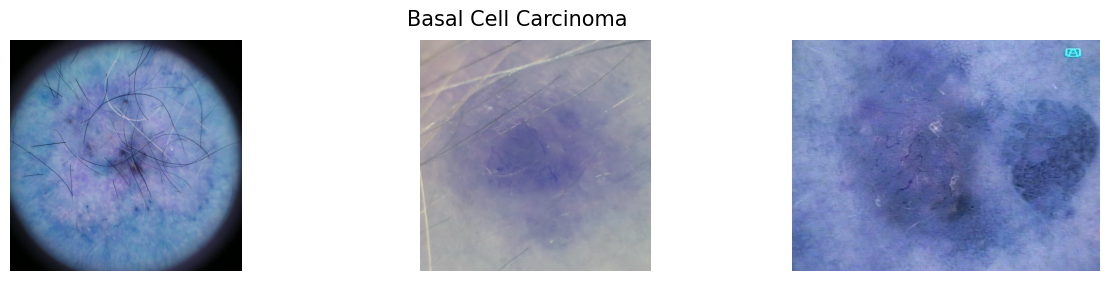

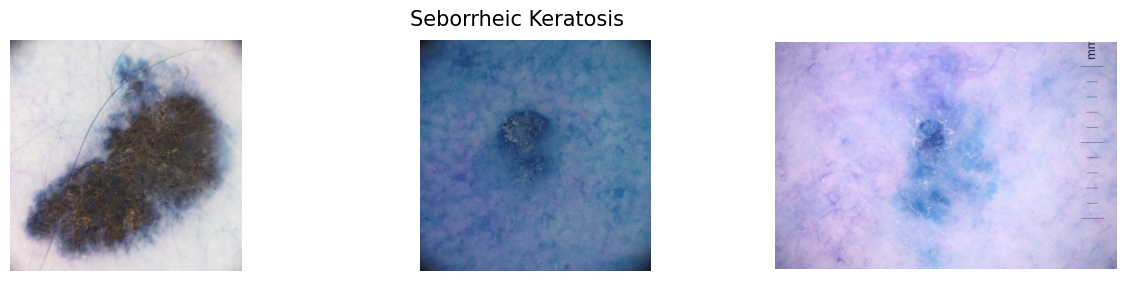

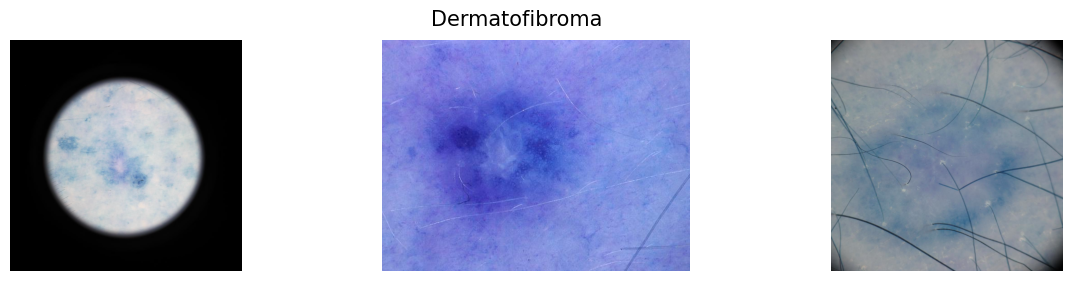

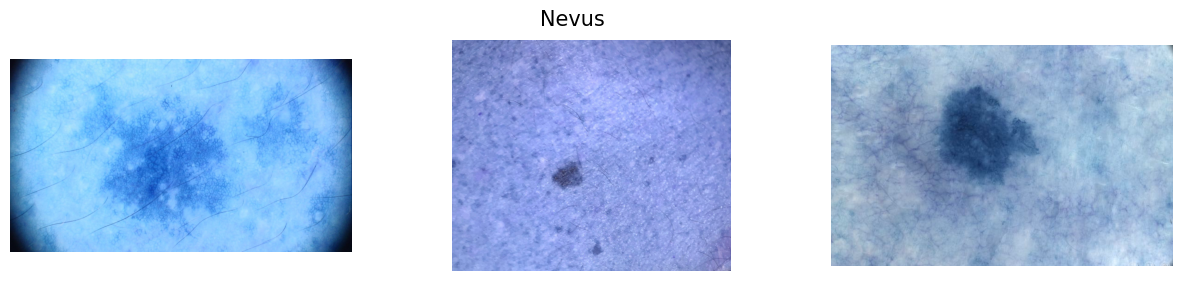

In [6]:
import cv2
import matplotlib.pyplot as plt
for cat in Class_found:
    # Construct the full path for the current category
    category_path = os.path.join(data_dir, cat)
    images = os.listdir(category_path)
    # Initialize a subplot with 1 row and 3 columns
    fig, ax = plt.subplots(1, 3, figsize=(15, 3))
    fig.suptitle(f'{cat}', fontsize=15)

    for i in range(3):
        # Randomly select an image
        img_name = images[np.random.randint(0, len(images))]
        img_path = os.path.join(category_path, img_name)
        img_array = cv2.imread(img_path)

        # Display the image
        ax[i].imshow(img_array)
        ax[i].axis('off')

In [7]:
full_image_path_list = []
labels = []
for cls in Class_found:
    # Construct the full path for the current category
    class_path = os.path.join(data_dir, cls)
    if not os.path.isdir(class_path):
        continue
    for img in os.listdir(class_path):
        full_image_path_list.append(os.path.join(class_path, img))
        labels.append(cls)

df = pd.DataFrame({
    "image_path": full_image_path_list,
    "label": labels
})


In [8]:
df['label_id'], uniques = pd.factorize(df['label'])
print("Class Names:", uniques.tolist())

Class Names: ['Acitinic Keratosis', 'Pigmented Benign Keratosis', 'Melanoma', 'Vascular Lesion', 'Squamous Cell Carcinoma', 'Basal Cell Carcinoma', 'Seborrheic Keratosis', 'Dermatofibroma', 'Nevus']


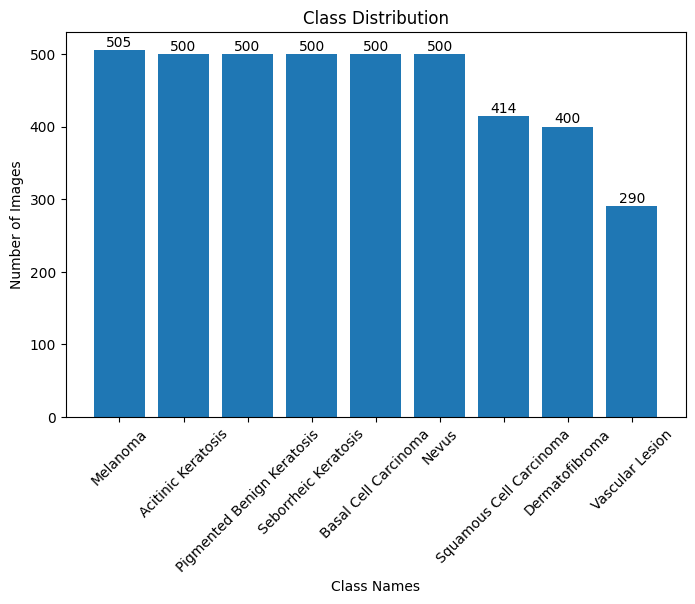

In [10]:
class_counts = df['label'].value_counts()

# Create bar chart
plt.figure(figsize=(8, 5))
plt.bar(class_counts.index, class_counts.values)

# Labels and title
plt.xlabel("Class Names")
plt.ylabel("Number of Images")
plt.title("Class Distribution")

# Rotate labels for better visibility
plt.xticks(rotation=45)

# Show values on top of bars
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 5, str(v), ha='center')

plt.show()

In [12]:
from sklearn.model_selection import train_test_split

X = df['image_path']
y = df['label_id']

In [13]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [16]:
train_df = pd.DataFrame({'image_path': X_train, 'label_id': y_train}).reset_index(drop=True)
val_df   = pd.DataFrame({'image_path': X_val, 'label_id': y_val}).reset_index(drop=True)
test_df  = pd.DataFrame({'image_path': X_test, 'label_id': y_test}).reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

Train size: 3287
Val size: 411
Test size: 411


In [17]:
train_patients = set(train_df['image_path'])
val_patients = set(val_df['image_path'])
test_patients = set(test_df['image_path'])

print("Train-Val overlap:", len(train_patients & val_patients))
print("Train-Test overlap:", len(train_patients & test_patients))
print("Val-Test overlap:", len(val_patients & test_patients))

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [19]:
print(train_df['label_id'].value_counts(normalize=True))
print(val_df['label_id'].value_counts(normalize=True))
print(test_df['label_id'].value_counts(normalize=True))

label_id
2    0.122908
0    0.121692
6    0.121692
1    0.121692
5    0.121692
8    0.121692
4    0.100700
7    0.097353
3    0.070581
Name: proportion, dtype: float64
label_id
2    0.121655
5    0.121655
1    0.121655
6    0.121655
0    0.121655
8    0.121655
4    0.102190
7    0.097324
3    0.070560
Name: proportion, dtype: float64
label_id
2    0.124088
0    0.121655
6    0.121655
8    0.121655
5    0.121655
1    0.121655
4    0.099757
7    0.097324
3    0.070560
Name: proportion, dtype: float64


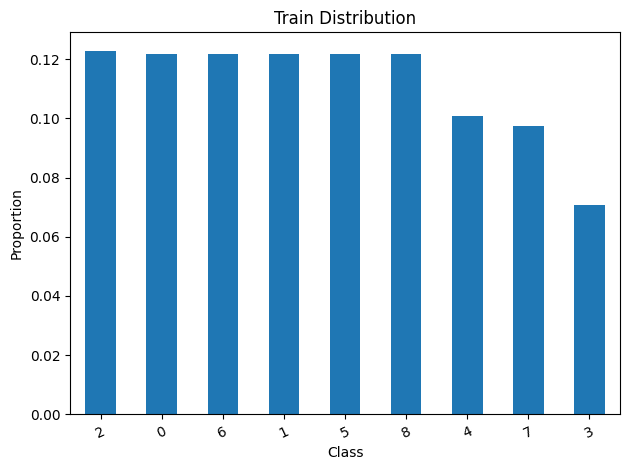

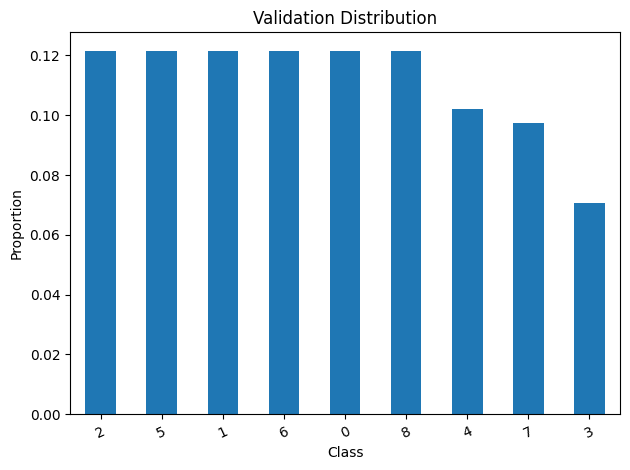

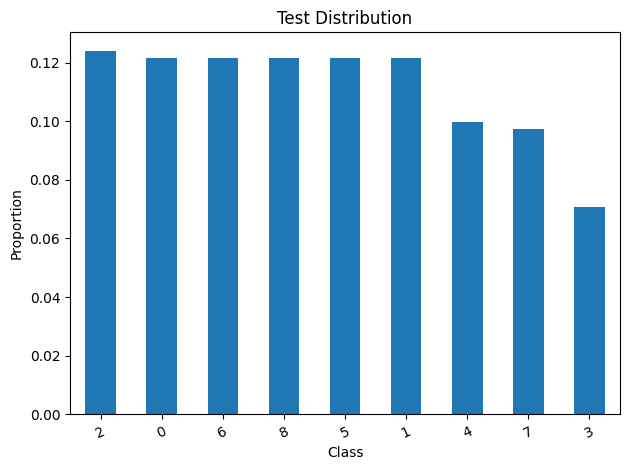

In [20]:
def plot_dist(df, title):
    df['label_id'].value_counts(normalize=True).plot(
        kind='bar'
    )
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Proportion")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

plot_dist(train_df, "Train Distribution")
plot_dist(val_df, "Validation Distribution")
plot_dist(test_df, "Test Distribution")